# Step 2: 분류 모델링 & 교차 검증
## 알고리즘: Random Forest Classifier

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("=" * 60)
print("  [Step 2] Random Forest 분류 모델링 & k-Fold 교차 검증")
print("=" * 60)

# [2-0] csv loading
print("\n[2-0] Processed CSV Loading...")

train_df = pd.read_csv('sp500_train_processed.csv')
test_df = pd.read_csv('sp500_test_processed.csv')

# Feature / Target 정의
feature_cols = [
    'Return',
    'volume',
    'MACD',
    'RSI',
    'Name_Encoded'
]

target_col = 'Target'

X_train_scaled = train_df[feature_cols]
y_train = train_df[target_col]
X_test_scaled = test_df[feature_cols]
y_test = test_df[target_col]

print("\nFeature Columns:")
print(feature_cols)

  [Step 2] Random Forest 분류 모델링 & k-Fold 교차 검증

[2-0] Processed CSV Loading...

Feature Columns:
['Return', 'volume', 'MACD', 'RSI', 'Name_Encoded']


## [2-1] 모델 정의 & [2-2] k-Fold 교차 검증 (k=5)

In [2]:
# [2-1] 모델 정의
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,             
    min_samples_leaf=50,       # 리프 노드의 최소 샘플 수 제한 (과적합 방지)
    class_weight='balanced',   # '무조건 상승'으로 찍는 쏠림 현상 방지
    n_jobs=-1,                 # 병렬 연산으로 대용량 데이터 처리 속도 향상
    random_state=42
)

print("\n[2-1] 모델: Random Forest")


# [2-2] k-Fold 교차 검증 (k=5)
print("\n[2-2] K-Fold 교차 검증(k=5)")
print("-" * 60)

K = 5

skf = StratifiedKFold(
    n_splits=K,
    shuffle=True,
    random_state=42
)

# 교차 검증
scores = cross_validate(
    model,
    X_train_scaled,
    y_train,
    cv=skf,
    scoring=[
        'accuracy',
        'precision',
        'recall',
        'f1'
    ],
    return_train_score=False
)

print(f"  Fold별 Accuracy  : {np.round(scores['test_accuracy'], 4)}")
print(f"  Fold별 F1-Score  : {np.round(scores['test_f1'], 4)}")
print()
print(f"  Average Accuracy  : {scores['test_accuracy'].mean():.4f} ± {scores['test_accuracy'].std():.4f}")
print(f"  Average Precision : {scores['test_precision'].mean():.4f} ± {scores['test_precision'].std():.4f}")
print(f"  Average Recall    : {scores['test_recall'].mean():.4f} ± {scores['test_recall'].std():.4f}")
print(f"  Average F1-Score  : {scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}")


[2-1] 모델: Random Forest

[2-2] K-Fold 교차 검증(k=5)
------------------------------------------------------------
  Fold별 Accuracy  : [0.5181 0.5169 0.5159 0.5196 0.5197]
  Fold별 F1-Score  : [0.543  0.544  0.535  0.5413 0.5475]

  Average Accuracy  : 0.5180 ± 0.0015
  Average Precision : 0.5345 ± 0.0013
  Average Recall    : 0.5501 ± 0.0080
  Average F1-Score  : 0.5421 ± 0.0041


## [2-3] 테스트셋 평가, [2-4] 종합 시각화 & [2-5] Feature Importance 출력


[2-3] 테스트셋 평가
------------------------------------------------------------
Accuracy : 0.5066
Precision: 0.5307
Recall   : 0.5246
F1-Score : 0.5276

[2-4] 시각화


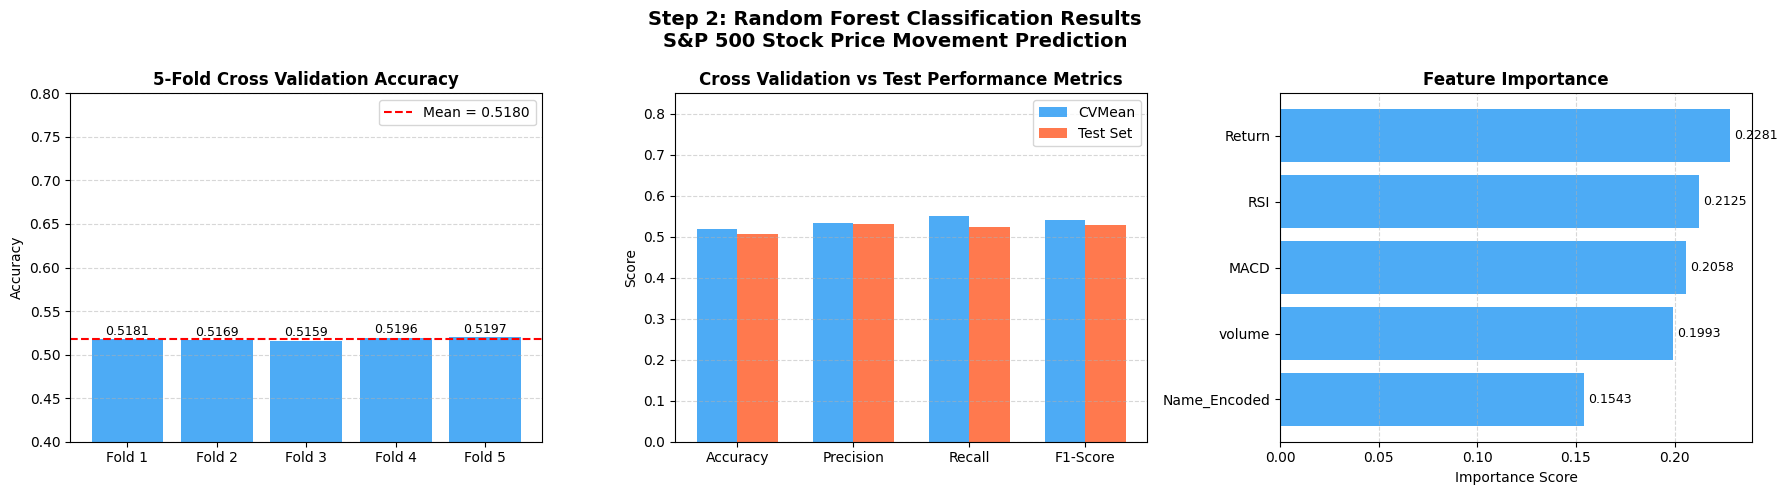


[2-5] Feature Importance
------------------------------------------------------------
     Feature  Importance
      Return    0.228134
         RSI    0.212505
        MACD    0.205756
      volume    0.199304
Name_Encoded    0.154300

Accuracy : 0.5066
Precision: 0.5307
Recall   : 0.5246
F1-Score : 0.5276


In [3]:
# [2-3] 테스트셋 평가
print("\n[2-3] 테스트셋 평가")
print("-" * 60)

# 모델 학습
model.fit(X_train_scaled, y_train)

# 예측 수행
y_pred = model.predict(X_test_scaled)

# 성능 지표 계산
test_acc = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {test_acc:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-Score : {test_f1:.4f}")


# [2-4] 종합 시각화 
print("\n[2-4] 시각화")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))  

fig.suptitle(
    'Step 2: Random Forest Classification Results\nS&P 500 Stock Price Movement Prediction',
    fontsize=14,
    fontweight='bold'
)

# 1. k-Fold Accuracy 막대 그래프
ax = axes[0]
fold_labels = [f'Fold {i+1}' for i in range(K)]
bars = ax.bar(
    fold_labels,
    scores['test_accuracy'],
    color='#2196F3',
    alpha=0.8
)

ax.axhline(
    scores['test_accuracy'].mean(),
    color='red',
    linestyle='--',
    label=f"Mean = {scores['test_accuracy'].mean():.4f}"
)
ax.set_title(f'{K}-Fold Cross Validation Accuracy', fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.4, 0.8)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

for bar, val in zip(bars, scores['test_accuracy']):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        val + 0.005,
        f'{val:.4f}',
        ha='center',
        fontsize=9
    )

# 2. 성능 지표 비교 그래프 (CV vs Test)
ax = axes[1]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
cv_vals = [
    scores['test_accuracy'].mean(),
    scores['test_precision'].mean(),
    scores['test_recall'].mean(),
    scores['test_f1'].mean()
]
test_vals = [test_acc, test_precision, test_recall, test_f1]

x = np.arange(len(metrics))
w = 0.35

ax.bar(x - w/2, cv_vals, w, label='CVMean', color='#2196F3', alpha=0.8)
ax.bar(x + w/2, test_vals, w, label='Test Set', color='#FF5722', alpha=0.8)
ax.set_title('Cross Validation vs Test Performance Metrics', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 0.85)
ax.set_ylabel('Score')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

# 3. Feature Importance 그래프
ax = axes[2]
feat_imp_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': model.feature_importances_
})
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=False)

bars = ax.barh(
    feat_imp_df['Feature'],
    feat_imp_df['Importance'],
    color='#2196F3',
    alpha=0.8
)
ax.set_title('Feature Importance', fontweight='bold')
ax.set_xlabel('Importance Score')
ax.invert_yaxis()
ax.grid(axis='x', linestyle='--', alpha=0.5)

for bar, val in zip(bars, feat_imp_df['Importance']):
    ax.text(
        val + 0.002,
        bar.get_y() + bar.get_height()/2,
        f'{val:.4f}',
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.savefig(
    'classification_result.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()


# [2-5] Feature Importance 출력
print("\n[2-5] Feature Importance")
print("-" * 60)
print(feat_imp_df.to_string(index=False))

print("\n" + "=" * 60)
print(f"Accuracy : {test_acc:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-Score : {test_f1:.4f}")
print("=" * 60)